In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp
import h5py
from astropy.io import fits
from astropy.table import Table

from msfm.utils import files

In [2]:
conf = files.load_config("../configs/v16/default.yaml")
cat_dir = conf["dirs"]["catalog"]
z_bins = conf["survey"]["metacal"]["z_bins"]  # ['metacal1', 'metacal2', 'metacal3', 'metacal4']

n_side = 4096
n_pix = hp.nside2npix(n_side)
print(f"n_side={n_side}, n_pix={n_pix}, z_bins={z_bins}")

n_side=4096, n_pix=201326592, z_bins=['metacal1', 'metacal2', 'metacal3', 'metacal4']


### Load metacal catalogs

Galaxies are kept at their original sky positions (no footprint rotation, unlike `catalog.py`).
Photo-z uses `zmc_sof` from the DNF catalog.

In [3]:
index = h5py.File(f"{cat_dir}/DESY3_indexcat.h5", "r")
gold  = h5py.File(f"{cat_dir}/DESY3_GOLD_2_2.1.h5", "r")
dnf   = h5py.File(f"{cat_dir}/DESY3_GOLD_2_2.1_DNF.h5", "r")

catalogs   = {}  # ra, dec, z per bin
count_maps = {}  # nside=4096 count map per bin

for i, z_bin in enumerate(z_bins):
    metacal_bin = index[f"/index/select_bin{i+1}"][:]

    ra  = gold["/catalog/gold/ra" ][:][metacal_bin].astype(np.float32)
    dec = gold["/catalog/gold/dec"][:][metacal_bin].astype(np.float32)
    z   = dnf[ "/catalog/unsheared/zmc_sof"][:][metacal_bin].astype(np.float32)

    # HEALPix pixels in original sky coordinates (no rotation)
    theta = -np.deg2rad(dec) + np.pi / 2  # healpy convention
    phi   =  np.deg2rad(ra)
    pix   = hp.ang2pix(n_side, theta, phi)

    count_map = np.bincount(pix, minlength=n_pix).astype(np.int32)

    catalogs[z_bin]   = {"ra": ra, "dec": dec, "z": z}
    count_maps[z_bin] = count_map

    print(f"{z_bin}: N_gal={len(ra):,}, non-empty pixels={np.sum(count_map > 0):,}")

index.close()
gold.close()
dnf.close()

metacal1: N_gal=24,940,465, non-empty pixels=13,759,035
metacal2: N_gal=25,280,405, non-empty pixels=13,790,712
metacal3: N_gal=24,891,859, non-empty pixels=13,566,366
metacal4: N_gal=25,091,297, non-empty pixels=13,560,812


### Mollview plots

/tmp/ipykernel_9155/2685730067.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


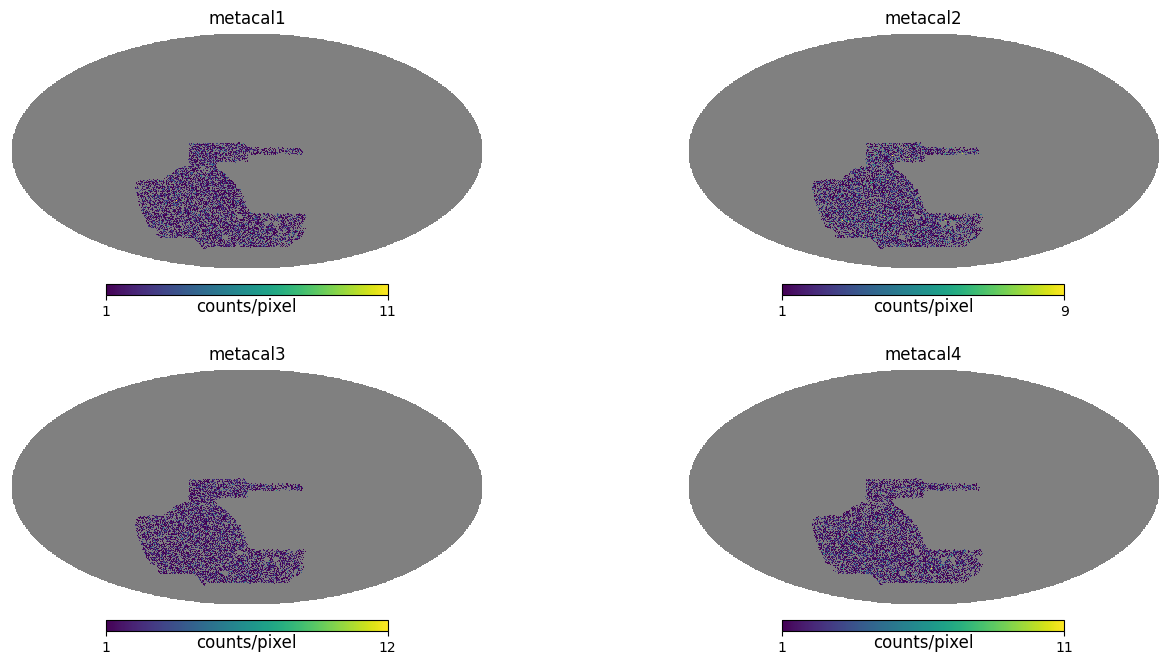

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, z_bin in zip(axes.flat, z_bins):
    plt.sca(ax)
    m = count_maps[z_bin].astype(float)
    m[m == 0] = hp.UNSEEN
    hp.mollview(m, title=z_bin, unit="counts/pixel", hold=True)
plt.tight_layout()
plt.show()

### Write HDF5

In [5]:
out_h5 = "../data/metacal.h5"

with h5py.File(out_h5, "w") as f:
    for z_bin in z_bins:
        grp = f.create_group(z_bin)
        grp.create_dataset("ra",        data=catalogs[z_bin]["ra"],  dtype="f4")
        grp.create_dataset("dec",       data=catalogs[z_bin]["dec"], dtype="f4")
        grp.create_dataset("z",         data=catalogs[z_bin]["z"],   dtype="f4")
        grp.create_dataset("count_map", data=count_maps[z_bin],      dtype=np.int32)

print(f"Saved {out_h5}")

Saved ../data/metacal.h5


### Write FITS

One `BinTableHDU` per bin for the galaxy catalog (RA, DEC, Z) and one `ImageHDU` per bin for the count map.

In [6]:
out_fits = "../data/metacal.fits"

hdul = fits.HDUList([fits.PrimaryHDU()])
for z_bin in z_bins:
    t = Table({
        "ra":  catalogs[z_bin]["ra"],
        "dec": catalogs[z_bin]["dec"],
        "z":   catalogs[z_bin]["z"],
    })
    hdul.append(fits.BinTableHDU(t, name=f"{z_bin}_cat"))
    hdul.append(fits.ImageHDU(data=count_maps[z_bin], name=f"{z_bin}_map"))

hdul.writeto(out_fits, overwrite=True)
print(f"Saved {out_fits}")
hdul.info()

Saved ../data/metacal.fits
Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  METACAL1_CAT    1 BinTableHDU     15   24940465R x 3C   ['E', 'E', 'E']   
  2  METACAL1_MAP    1 ImageHDU         7   (201326592,)   int32   
  3  METACAL2_CAT    1 BinTableHDU     15   25280405R x 3C   ['E', 'E', 'E']   
  4  METACAL2_MAP    1 ImageHDU         7   (201326592,)   int32   
  5  METACAL3_CAT    1 BinTableHDU     15   24891859R x 3C   ['E', 'E', 'E']   
  6  METACAL3_MAP    1 ImageHDU         7   (201326592,)   int32   
  7  METACAL4_CAT    1 BinTableHDU     15   25091297R x 3C   ['E', 'E', 'E']   
  8  METACAL4_MAP    1 ImageHDU         7   (201326592,)   int32   
